<a href="https://colab.research.google.com/github/DeepanshuSharma1607/langgraph/blob/main/langgrah_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install uv
!uv pip install langchain-mistralai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.3/26.3 MB 64.8 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 46 packages in 842ms
Prepared 2 packages in 16ms
Installed 2 packages in 3ms
 + httpx-sse==0.4.3
 + langchain-mistralai==1.1.5


In [ ]:
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage
)
from langgraph.graph import StateGraph , MessagesState , START , END , add_messages
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
import requests
from rich import print
from pprint import pprint
from langchain.tools import tool
from typing import TypedDict
from operator import add
from typing import Annotated

In [ ]:
CHAT_MISTRAL_API_KEY = "use your api"

In [ ]:
llm = ChatMistralAI(
    model="mistral-small-2506",
    api_key= CHAT_MISTRAL_API_KEY,
    temperature = 0.5
)

In [ ]:
result = llm.invoke("hello")

In [ ]:
class Payment(TypedDict):
  pay_status : str

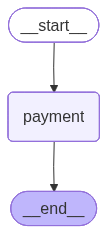

In [ ]:
from langgraph.types import Checkpointer
def payment_status(state : Payment):
  return {"pay_status":"paid"}

builder1 = StateGraph(Payment)
builder1.add_node('payment',payment_status)

builder1.add_edge(START , "payment")
builder1.add_edge("payment" , END)

memory = MemorySaver()
graph1 = builder1.compile(checkpointer = memory)
display(Image(graph1.get_graph().draw_mermaid_png()))

In [ ]:
class Order(TypedDict):
  order_status : str

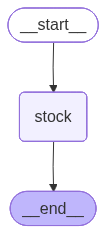

In [ ]:
from langgraph.types import Checkpointer
def stock(state : Order):
  return {"order_status":"buyed"}

builder2 = StateGraph(Order)
builder2.add_node('stock',stock)

builder2.add_edge(START , "stock")
builder2.add_edge("stock" , END)

memory = MemorySaver()
graph2 = builder2.compile(checkpointer = memory)
display(Image(graph2.get_graph().draw_mermaid_png()))

In [ ]:
class Final(TypedDict):
  order_id:int
  order_status:str


In [ ]:
def order(final : Final):
  return {'order_id':final['order_id'][-1]}

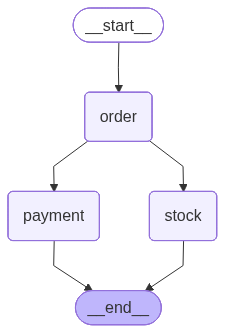

In [ ]:
builder = StateGraph(Final)
builder.add_node('order',order)
builder.add_node('payment', graph1)
builder.add_node('stock', graph2)
builder.add_edge(START , 'order')
builder.add_edge('order','stock')
builder.add_edge('order','payment')
builder.add_edge('stock' , END)
builder.add_edge('payment' , END)
memory = MemorySaver()
graph = builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
thread = {"configurable": {"thread_id": "1"}}
result = graph.invoke({'order_id':[1]},thread)
print(result)

{'order_id': 1, 'order_status': 'buyed'}

In [ ]:
result = graph.invoke({'order_id':[2]},thread)
print(result)


{'order_id': 2, 'order_status': 'buyed'}

In [ ]:
from pydantic import BaseModel

In [ ]:
subjects_prompt = """Generate a list of 3 sub-topics that are all related to this overall topic: {topic}."""
joke_prompt = """Generate a joke about {subject}"""
best_joke_prompt = """Below are a bunch of jokes about {topic}. Select the best one! Return the ID of the best one, starting 0 as the ID for the first joke. Jokes: \n\n  {jokes}"""

In [ ]:
class OverallState(TypedDict):
  topic:str
  subject : list
  jokes : Annotated[list , add]
  best_joke : str

class Subjects(BaseModel):
  subject: list[str]

class BestJoke(BaseModel):
  id : int

In [ ]:
def generate_topic(state : OverallState):
  prompt = subjects_prompt.format(topic = state['topic'])
  result = llm.with_structured_output(Subjects).invoke(prompt)